# Derivation for a general integration identity involving sech

This notebook checks a general integration identity for functions involving sech and a power of a the variable of integration, i.e.

$$
\int \! \xi^j \mathrm{sech(a\xi + b)} \, \mathrm{d\xi} =
-2 \sum_{k=0}^n \frac{n! \xi^{n-k} \mathrm{Ti}\left( e^{-a\xi - b} \right) }{(n-k)! a^{k+1}} .
\label{eq:sech_integral} \tag{1}
$$

Here $\mathrm{Ti}_k(z)$ is the Inverse Tangent Integral

$$
\mathrm{Ti}_k(z) = \frac{1}{2i}\left(\mathrm{Li}_s(iz) - \mathrm{Li}_s(-iz) \right)
\label{eq:inv_tan_integrat} \tag{2}
$$

such that the integral above can also be written:

$$
\int \! \xi^j \mathrm{sech(a\xi + b)} \, \mathrm{d\xi} =
i \sum_{k=0}^{n} \frac{n! \xi^{n-k}}{(n-k)! a^{k+1}}
    \left( \mathrm{Li}_{k+1}\left( i e^{-a\xi -b} \right) - \mathrm{Li}_{k+1}\left( -i e^{-a\xi -b} \right)\right)
$$


This notebook also serves as an example of how to easily interact with the Wolfram Language through Python.

In [2]:
# Wolfram Language Imports
from wolframclient.evaluation import WolframLanguageSession
from wolframclient.language import wl, wlexpr
ws = WolframLanguageSession()

# Display Latex
from IPython.display import display, Math


In [20]:
from PIL import Image
import io

## Helper functions

Here we define some helper functions to help print pretty outputs.

In [3]:
def print_tex(expr):
    """Prints an expression in latex"""
    display(Math(expr))

def print_wlresult(expr):
    """Prints a wolfram language result in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(expr)))
    display(Math(tex_expr))

def print_wlexpr(expr):
    """Prints a wolfram language expression in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(ws.evaluate(expr))))
    display(Math(tex_expr))
    
def eval_wlprint(expr):
    """Evaluates an expression, stores, and prints the result"""
    result = ws.evaluate(expr)
    save_expr_str = 'rrr = {}'.format(expr)
    ws.evaluate(save_expr_str)
    print_wlresult(ws.evaluate('rrr'))

print('\nPrinting latex:')
print_tex('\sum_{i=1}^{10} x_i')

print('\nPrinting the result of an evaluated expression:')
print_wlresult(ws.evaluate('x+2+y+3'))

print('\nEvaluating and printing an expression directly:')
print_wlexpr('Sum[x^k, {k, 0, 5}]')

print('\nEvaluating, storing, and printing reults:')
eval_wlprint('Sum[x^k, {k, 0, 5}]')

print('\nAccessing those results in the variable "rrr":')
eval_wlprint('rrr*10 + y')


Printing latex:


<IPython.core.display.Math object>


Printing the result of an evaluated expression:


<IPython.core.display.Math object>


Evaluating and printing an expression directly:


<IPython.core.display.Math object>


Evaluating, storing, and printing reults:


<IPython.core.display.Math object>


Accessing those results in the variable "rrr":


<IPython.core.display.Math object>

## Check the identity

Check the derived identity using the Wolfram Client.

Checking the substitutions:
Clearing the wolfram session:
Defining the Inverse Tangent Integral:


<IPython.core.display.Math object>

Defining j:


<IPython.core.display.Math object>

LHS - Integrating symbolically:


<IPython.core.display.Math object>

RHS - Integrating via the formula:


<IPython.core.display.Math object>

Plotting both sides:


Invalid integration variable or limit(s) in 0.000102143.
Invalid integration variable or limit(s) in 0.102143.
Invalid integration variable or limit(s) in 0.204184.
Invalid integration variable or limit(s) in 0.306225.
Invalid integration variable or limit(s) in 0.408265.
Invalid integration variable or limit(s) in 0.510306.
Invalid integration variable or limit(s) in 0.612347.
Invalid integration variable or limit(s) in 0.714388.
Invalid integration variable or limit(s) in 0.816429.
Invalid integration variable or limit(s) in 0.918469.
Invalid integration variable or limit(s) in 1.02051.
Invalid integration variable or limit(s) in 1.12255.
Invalid integration variable or limit(s) in 1.22459.
Invalid integration variable or limit(s) in 1.32663.
Invalid integration variable or limit(s) in 1.42867.
Invalid integration variable or limit(s) in 1.53071.
Invalid integration variable or limit(s) in 1.63276.
Invalid integration variable or limit(s) in 1.7348.
Invalid integration variable or li

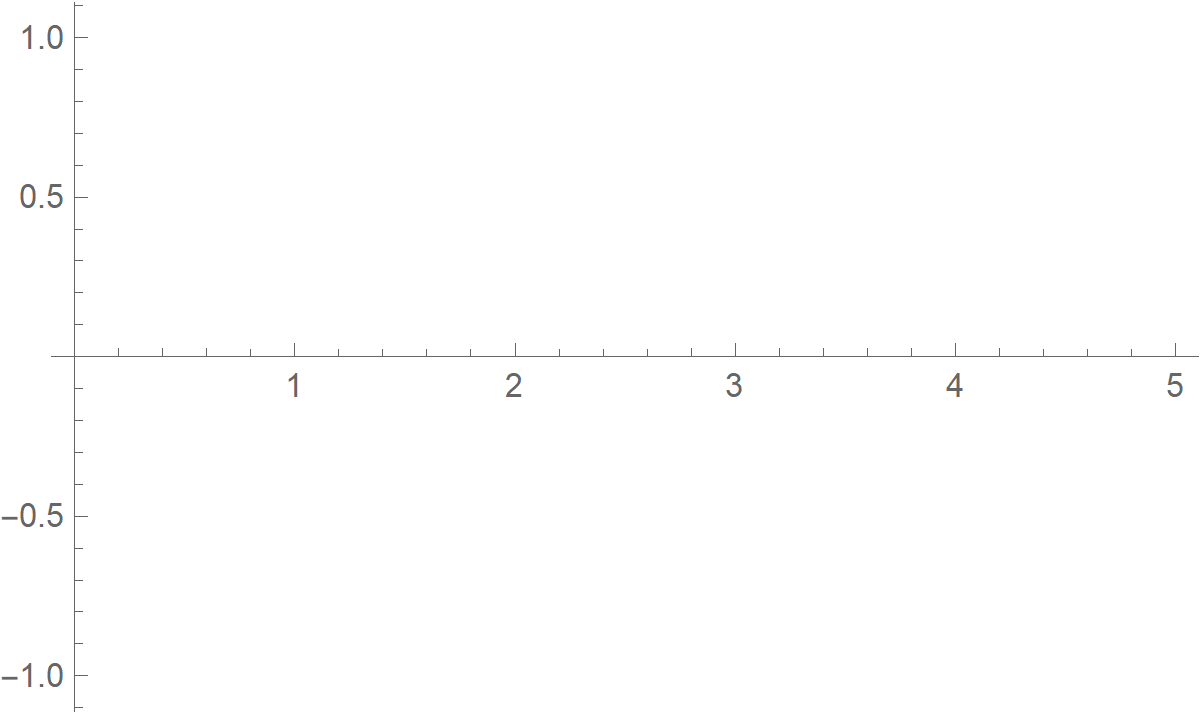

In [25]:
print('Checking the substitutions:')

# Clear all variables in the wolfram sessions
print('Clearing the wolfram session:')
wl.Clear("Global`*")

# Define the Inverse Tangent Integral
print('Defining the Inverse Tangent Integral:')
eval_wlprint('Ti[s_, z_] := 1/(2*I)*(PolyLog[s, I*z] - PolyLog[s, -I*z])')

# Define the parameter j
print('Defining j:')
eval_wlprint('j = 1')

print('LHS - Integrating symbolically:')
print_wlexpr('''
LHS[x_] := FullSimplify[Integrate[x^j * Sech[a*x], x]]
''')

print('RHS - Integrating via the formula:')
print_wlexpr('''
RHS[x_] := FullSimplify[-2*Sum[(j! * x^(j-k)*Ti[k+1, Exp[a*x]])/((j-k)! * a^(k+1)) , {k, 0, j}]]
''')

# Check if the integral is equalivalent to the summation
#print('Checking equality analytically:')
#print_wlexpr('FullSimplify[L == R]')

print('Plotting both sides:')
plot = ws.evaluate(wlexpr('Plot[{LHS[x], RHS[x]}, {x, 0, 5}]'))
img_data = ws.evaluate(wl.ExportByteArray(plot, 'PNG'))
Image.open(io.BytesIO(img_data))


In [1]:
ws.stop()

NameError: name 'ws' is not defined